# Единицы измерения

Справочник единиц из DMF и то, как он стыкуется с `code_unit` в атрибутных наборах пилотных классов.



## Подготовка



In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
plt.rcParams.update(
    {
        "figure.figsize": (7, 3.5),
        "axes.grid": True,
        "axes.axisbelow": True,
        "font.size": 11,
        "font.family": "DejaVu Sans",
    }
)

CLASS_LABEL = {
    "bak": "Баки",
    "heat_exchanger": "Теплообменники",
    "strainer": "Фильтры сетчатые",
}
CLASS_ORDER = ["bak", "heat_exchanger", "strainer"]


def resolve_data_root() -> Path:
    env = os.environ.get("NSI_DATA_ROOT")
    candidates: list[Path] = []
    if env:
        candidates.append(Path(env).expanduser())
    candidates.append(Path.home() / "projects/nsi-attribute-extraction/data.local")
    cwd = Path.cwd()
    candidates.extend(
        [
            cwd / "data.local",
            cwd.parent / "nsi-attribute-extraction" / "data.local",
        ]
    )
    for c in candidates:
        if (c / "input_data_ukidim").is_dir():
            return c.resolve()
    raise FileNotFoundError("Не найден data.local/input_data_ukidim. Укажите NSI_DATA_ROOT.")


DATA = resolve_data_root()
UKI = DATA / "input_data_ukidim"
DMF_PATH = next(UKI.glob("*DMF*.xlsb"))
print("DATA =", DATA)
print("DMF =", DMF_PATH.name)



DATA = /home/fyodebadylo/projects/nsi-attribute-extraction/data.local
DMF = Единицы измерения из DMF.xlsb


## Что лежит в DMF

Справочник двухуровневый: группа величины (давление, температура, …) и допустимые единицы внутри группы.



In [2]:
raw = pd.read_excel(DMF_PATH, sheet_name="Статус DMF на дату", engine="pyxlsb", header=None)
dmf = raw.iloc[6:].copy()
dmf = dmf.rename(
    columns={
        0: "group_ru",
        1: "group_en",
        2: "group_code",
        3: "unit_ru",
        4: "unit_en",
        5: "symbol_ru",
        6: "symbol_en",
        7: "is_base",
        8: "factor",
        9: "offset",
    }
)
dmf["group_code"] = dmf["group_code"].astype(str).str.strip()
dmf = dmf[dmf["group_code"].str.startswith("DSN", na=False)].copy()

overview = pd.Series(
    {
        "строк (единиц)": len(dmf),
        "групп величин": int(dmf["group_code"].nunique()),
        "уникальных наименований ЕИ": int(dmf["unit_ru"].nunique()),
        "медиана ЕИ в группе": float(dmf.groupby("group_code").size().median()),
        "макс. ЕИ в группе": int(dmf.groupby("group_code").size().max()),
    },
    name="DMF",
).to_frame()
overview



,DMF
строк (единиц),468.0
групп величин,142.0
уникальных наименований ЕИ,416.0
медиана ЕИ в группе,3.0
макс. ЕИ в группе,15.0


cell_5:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


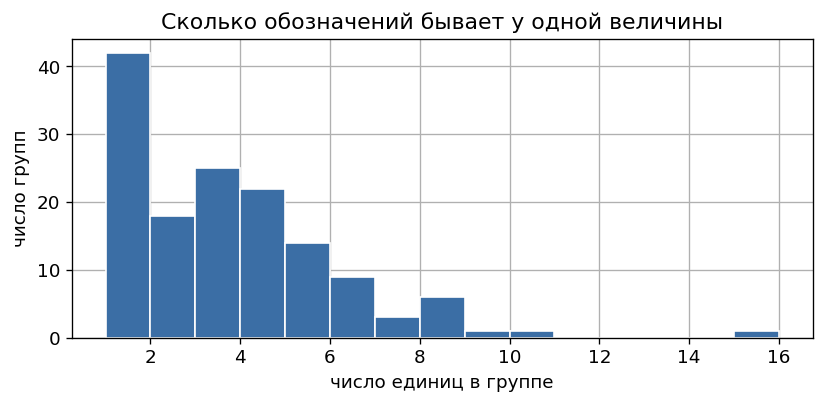

In [3]:
units_per_group = dmf.groupby("group_code").size()
fig, ax = plt.subplots()
ax.hist(units_per_group, bins=range(1, int(units_per_group.max()) + 2), color="#3b6ea5", edgecolor="white")
ax.set_xlabel("число единиц в группе")
ax.set_ylabel("число групп")
ax.set_title("Сколько обозначений бывает у одной величины")
plt.tight_layout()
plt.show()



**Вывод.** Одна физическая величина в справочнике — это не одна строка «МПа», а группа с несколькими допустимыми обозначениями. При сравнении ответов с эталоном единицы придётся нормализовать внутри группы, а не сравнивать строки as-is.



## Как пилотные атрибуты ссылаются на DMF

В `attributes_set` поле `code_unit` — код группы DMF (`DSN…`), а не конкретное обозначение вроде «МПа».



In [4]:
rows = []
all_codes: set[str] = set()
for code in CLASS_ORDER:
    attrs = pd.read_excel(UKI / "meta" / code / "attributes_set.xlsx")
    codes = set(attrs["code_unit"].dropna().astype(str))
    all_codes |= codes
    num = attrs[attrs["type"] == "number"]
    rows.append(
        {
            "класс": CLASS_LABEL[code],
            "атрибутов": len(attrs),
            "number": len(num),
            "number с code_unit": int(num["code_unit"].notna().sum()),
            "уникальных групп ЕИ": len(codes),
        }
    )

link = pd.DataFrame(rows)
link



,класс,атрибутов,number,number с code_unit,уникальных групп ЕИ
0,Баки,170,88,83,19
1,Теплообменники,183,118,107,16
2,Фильтры сетчатые,147,84,75,17


In [5]:
dmf_groups = set(dmf["group_code"])
coverage = pd.Series(
    {
        "групп ЕИ в пилотных справочниках": len(all_codes),
        "из них есть в DMF": len(all_codes & dmf_groups),
        "нет в DMF": len(all_codes - dmf_groups),
    },
    name="покрытие",
).to_frame()
coverage



,покрытие
групп ЕИ в пилотных справочниках,21
из них есть в DMF,21
нет в DMF,0


**Вывод.** Ссылка из атрибута идёт на группу величины, а не на конкретную ЕИ. Для пилотных классов все используемые `code_unit` находятся в DMF — стыковка справочников здесь чистая.



## Пример: что входит в одну группу

Берём несколько групп, которые чаще всего встречаются у number-атрибутов пилота.



In [6]:
# частоты code_unit по всем классам
freq = []
for code in CLASS_ORDER:
    attrs = pd.read_excel(UKI / "meta" / code / "attributes_set.xlsx")
    freq.append(attrs["code_unit"].dropna().astype(str))
freq_s = pd.concat(freq, ignore_index=True)
top_groups = freq_s.value_counts().head(5).index.tolist()

# названия групп из DMF
group_names = (
    dmf.drop_duplicates("group_code")
    .set_index("group_code")["group_ru"]
    .to_dict()
)

examples = []
for g in top_groups:
    sub = dmf.loc[dmf["group_code"] == g, ["symbol_ru", "unit_ru"]].drop_duplicates()
    examples.append(
        {
            "группа": g,
            "величина": group_names.get(g, ""),
            "атрибутов с этой группой": int((freq_s == g).sum()),
            "ЕИ в группе": len(sub),
            "обозначения": ", ".join(sub["symbol_ru"].astype(str).head(8)),
        }
    )
pd.DataFrame(examples)



,группа,величина,атрибутов с этой группой,ЕИ в группе,обозначения
0,DSN0000220,Время,78,9,"нс, мкс, мс, с, мес, год, ч, мин"
1,DSN0000304,Температура Цельсия,41,1,⁰C
2,DSN0000222,Давление,33,8,"мПа, Па (изб), Па, гПа, кПа, кПа (изб), МПа (изб), МПа"
3,DSN0000224,"Длина, ширина, высота, толщина, радиус, диаметр, расстояние, радиус кривизны",32,8,"нм, мкм, мм, см, дюйм, дм, м, км"
4,DSN0000302,Соотношение,14,2,"о.е., %"


**Вывод.** Даже частотные группы (время, давление, температура и т.п.) дают десяток допустимых написаний. Без справочника групп легко зачесть ошибкой эквивалентные единицы.



## Number без code_unit

Не у всех числовых атрибутов единица задана — смотрим долю.



In [7]:
bare = []
for code in CLASS_ORDER:
    attrs = pd.read_excel(UKI / "meta" / code / "attributes_set.xlsx")
    num = attrs[attrs["type"] == "number"]
    bare.append(
        {
            "класс": CLASS_LABEL[code],
            "number": len(num),
            "без code_unit": int(num["code_unit"].isna().sum()),
            "доля без ЕИ": round(float(num["code_unit"].isna().mean()), 3) if len(num) else None,
        }
    )
pd.DataFrame(bare)



,класс,number,без code_unit,доля без ЕИ
0,Баки,88,5,0.057
1,Теплообменники,118,11,0.093
2,Фильтры сетчатые,84,9,0.107


**Вывод.** Часть number-слотов — безразмерные или счётные величины. Правило «всегда требуй единицу» было бы слишком жёстким: единица обязательна там, где задан `code_unit`.



## Коротко

Единицы в DMF организованы группами величин; атрибут ссылается на группу, а не на конкретное обозначение; внутри группы много допустимых написаний; не у каждого number единица нужна. Это нужно учесть и при нормализации ответа, и при сравнении с эталоном.

